In [1]:
import sys
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Ellipse, Polygon
import matplotlib.ticker as mticker
#M = scaler.fit_transform(M)
scaler = MinMaxScaler()
import pandas as pd
from matplotlib.font_manager import FontProperties
import matplotlib as mpl
import sklearn
from scipy.signal import savgol_filter
import matplotlib.lines as mlines
import matplotlib.pyplot as plt

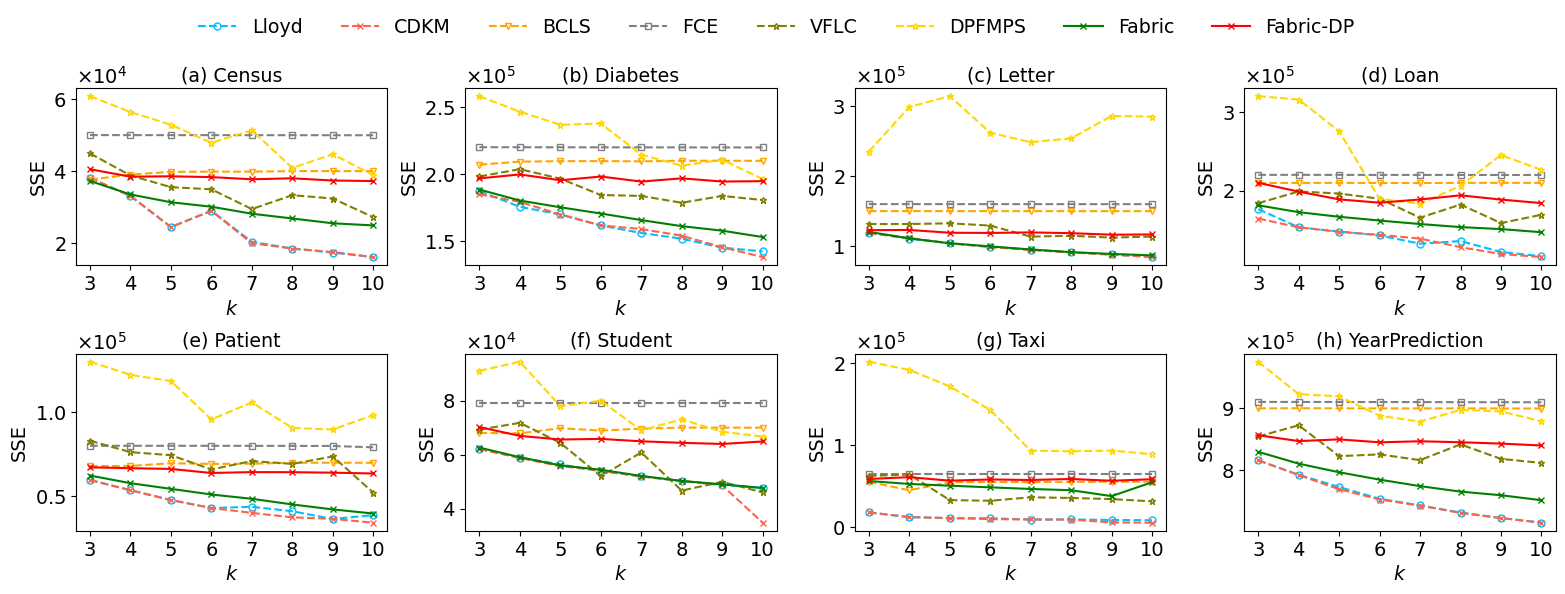

<Figure size 100x400 with 0 Axes>

In [17]:
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
marker = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["Lloyd","CDKM","BCLS", "FCE","VFLC", "DPFMPS","Fabric","Fabric-DP","x", "x"]
df = pd.read_csv('./fig1.csv')
df = df.to_numpy()

fs = 14
fig, axs = plt.subplots(2, 4, figsize=(16, 5.6)) 
fig.tight_layout()
plt.figure(figsize=(1,4))
makesize = 5
linestyle1= '-.'
def drawMapWithLabels(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'  # 最后两条用虚线
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1],
            label=labels[i - 1]
        )

def drawMap(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'  # 最后两条用虚线
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1]
        )



row_num = 8
drawMapWithLabels(0, row_num, axs[0,0])
drawMap(row_num * 1, row_num, axs[0,1])
drawMap(row_num * 2, row_num, axs[0,2])
drawMap(row_num * 3, row_num, axs[0,3])
drawMap(row_num * 4, row_num, axs[1,0])
drawMap(row_num * 5, row_num, axs[1,1])
drawMap(row_num * 6, row_num, axs[1,2])
drawMap(row_num * 7, row_num, axs[1,3])

fig.legend(loc='upper center',fontsize = fs*0.98, bbox_to_anchor=(0.5, 1.08),
          ncol=10, fancybox=False, shadow=False,frameon=False)


titles = ["(a) Census","(b) Diabetes","(c) Letter","(d) Loan","(e) Patient","(f) Student","(g) Taxi","(h) YearPrediction"]



for i in range(8):
    row = i // 4
    col = i % 4
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    axs[row,col].yaxis.set_major_formatter(formatter)
    axs[row,col].set_title(titles[i], fontsize = fs*0.98, pad=5)
    axs[row,col].set_ylabel('SSE', fontsize = fs)
    axs[row,col].set_xlabel("$k$", fontsize = fs*0.98)
    axs[row,col].set_xticks([1,2,3,4,5,6,7,8])
    axs[row,col].set_xticklabels(['3','4','5', '6','7','8','9','10'])
    

fig.tight_layout()
fig.subplots_adjust(wspace=0.25)
fig.subplots_adjust(hspace=0.5)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./SSE.pdf", format="pdf", bbox_inches="tight")
plt.show()

['Census', 'Diabetes', 'Letter', 'Loan', 'Patient', 'Student', 'Taxi', 'YearPrediction']


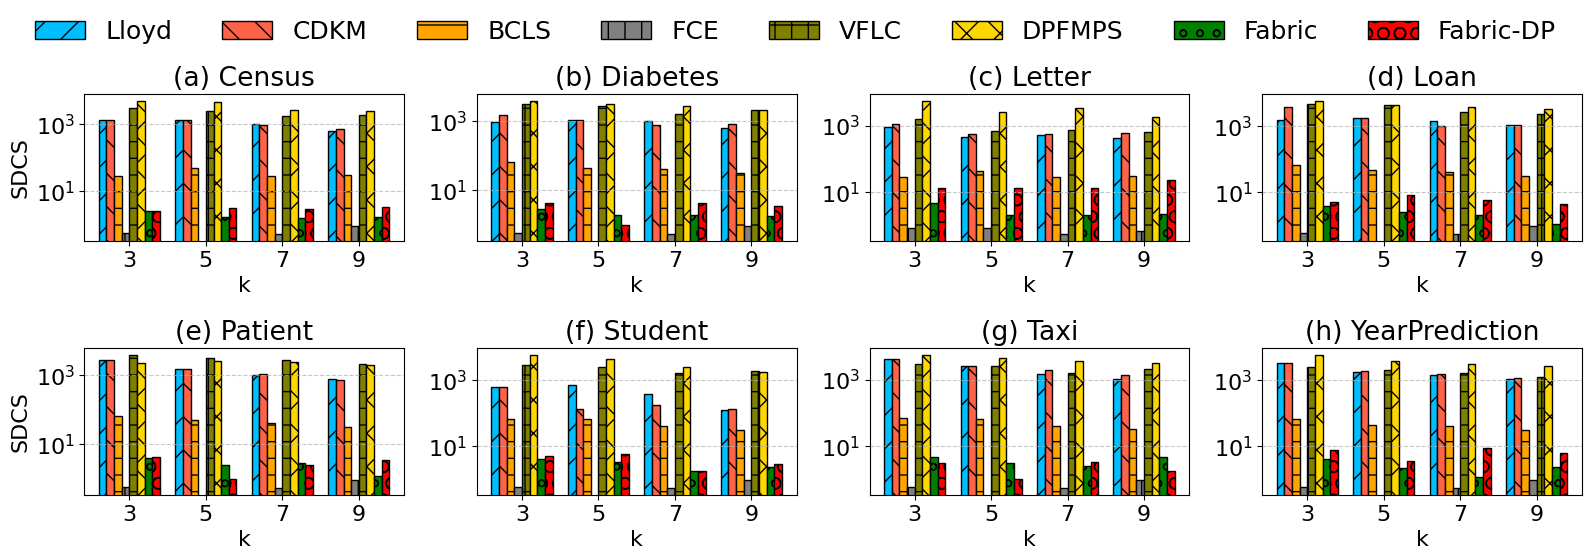

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib as mpl

# Matplotlib settings
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams.update({'font.size': 16})

# Define patterns and colors
patterns = ['/', '\\', '-', '|', '+', 'x', 'o', 'O', '.', '*']
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
# Load data from Excel
df = pd.read_excel('Balance.xlsx')

# Ensure the 'k' column is integer for sorting
df['k'] = df['k'].astype(int)

# Define available options
available_datasets = df['Dataset'].unique().tolist()
available_methods = df['Method'].unique().tolist()
available_k = sorted(df['k'].unique())



# User selections

selected_datasets = ['Census', 'Diabetes', 'Letter', 'Loan', 'Patient', 'Student', 'Taxi', 'YearPrediction']  
selected_methods = ["Lloyd","CDKM","BCLS", "FCE","VFLC", "DPFMPS","Fabric","Fabric-DP"]


selected_k = [3,  5,  7,  9]  # Select k-values to display

# Filter the DataFrame based on selections
filtered_df = df[
    df['Dataset'].isin(selected_datasets) &
    df['Method'].isin(selected_methods) &
    df['k'].isin(selected_k)
]

# Pivot the data for easier plotting
pivot_df = filtered_df.pivot_table(
    index=['Dataset', 'k'],
    columns='Method',
    values='SDCS'
).reset_index()

# Sort the DataFrame
pivot_df.sort_values(['Dataset', 'k'], inplace=True)

# Number of datasets to plot
num_datasets = len(selected_datasets)

# Determine subplot grid size (e.g., 2x4 for 8 datasets)
n_cols = 4
n_rows = int(np.ceil(num_datasets / n_cols))

# Create subplots
fig, axes = plt.subplots(2, 4, figsize=(16.2, 5.6))
# fig, axs = plt.subplots(1, 4, figsize=(16, 2.8))

axes = axes.flatten()  # Flatten in case of multiple rows


legend_elements = [
    Patch(
        facecolor=colors[i],
        label=method,
        hatch=patterns[i % len(patterns)],
        edgecolor='black'  
    ) 
    for i, method in enumerate(selected_methods)
]
print(selected_datasets)
# Plot each dataset
for idx, dataset in enumerate(selected_datasets):
    ax = axes[idx]
    data = pivot_df[pivot_df['Dataset'] == dataset]

  


    k_values = data['k'].tolist()
    x = np.arange(len(k_values))  # the label locations
    total_width = 0.8
    bar_width = total_width / len(selected_methods)

    for i, method in enumerate(selected_methods):
        balances = data[method].tolist()
        # Adjust the position for each method
        offset = (i - len(selected_methods)/2) * bar_width + bar_width/2
        ax.bar(
            x + offset, 
            balances, 
            bar_width, 
            label=method,
            color=colors[i % len(colors)],
            hatch=patterns[i % len(patterns)],
            edgecolor='black',  

        )

    ax.set_title(f'({chr(97 + idx)}) {dataset}')  
    ax.set_xlabel('k')
    ax.set_xticks(x)
    ax.set_xticklabels(k_values)
    if idx % n_cols == 0:
        ax.set_ylabel('SDCS')
    ax.set_yscale('log') 
    ax.grid(axis='y', linestyle='--', alpha=0.7)


legend = fig.legend(
    handles=legend_elements, 
    loc='upper center', 
    ncol=len(selected_methods), 
    bbox_to_anchor=(0.5, 1.03), 
    fontsize=18, 
    frameon=False, 
)


fig.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.savefig('Balance.pdf')
mpl.rcParams.update({'font.size': 14})
# Show plot
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_67148\1487982362.py:36: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_67148\1487982362.py:57: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_67148\1487982362.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


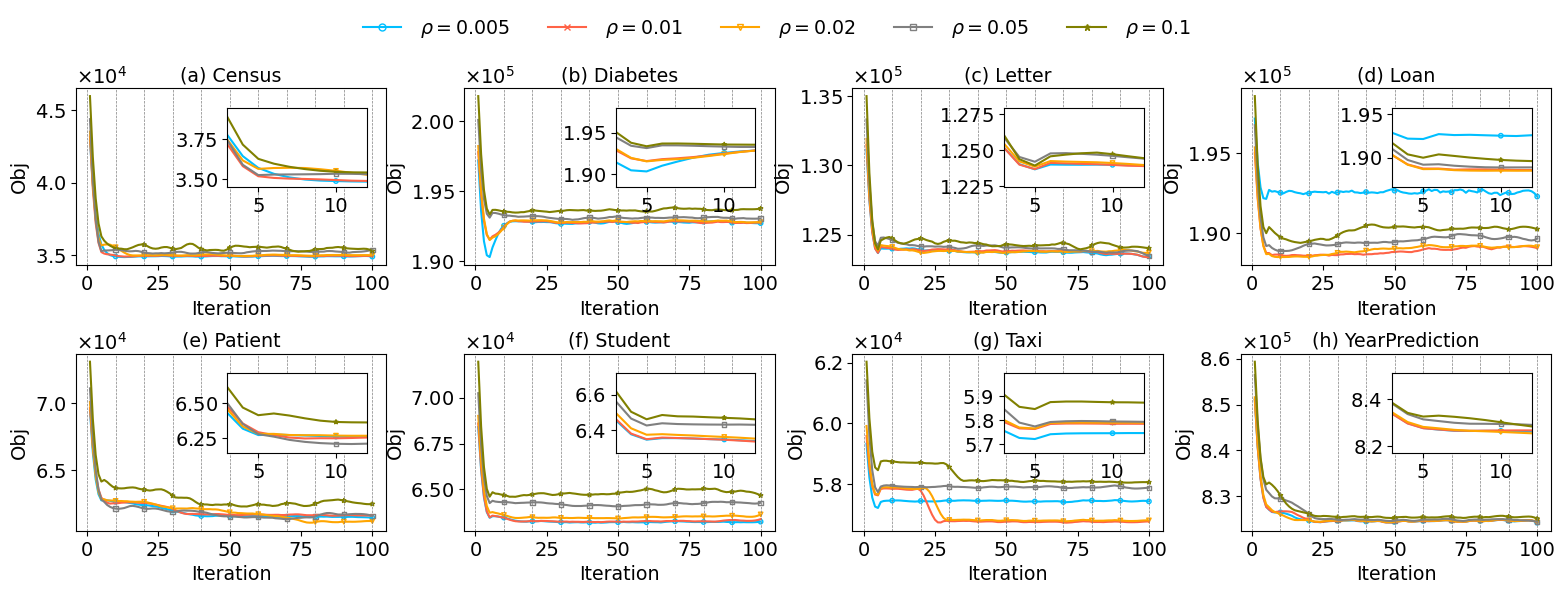

In [115]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib as mpl
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
markers = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["$\\rho=0.005$", "$\\rho=0.01$", "$\\rho=0.02$", "$\\rho=0.05$", "$\\rho=0.1$"]
titles = ["(a) Census","(b) Diabetes","(c) Letter","(d) Loan","(e) Patient","(f) Student","(g) Taxi","(h) YearPrediction"]

df = pd.read_csv('./fig3_1.csv', encoding='utf-8-sig').to_numpy()

makesize = np.zeros(len(df[0]))
makesize[np.mod(df[0], 10) == 0] = 10

fs = 14
fig, axs = plt.subplots(2, 4, figsize=(16, 5.6)) 
fig.tight_layout()

def smooth_data(data):
    return savgol_filter(data, window_length=10, polyorder=3)

def drawMapWithInset(start_row, row_num, ax, title):
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        ax.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                   edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    ax.set_title(title, fontsize=fs*0.98, pad=5)
    ax.set_ylabel('Obj', fontsize=fs)
    ax.set_xlabel("Iteration", fontsize=fs*0.98)

    for k in range(0, 11, 1):
        ax.axvline(x=k*10, color='gray', linestyle='--', linewidth=0.5)

    axins = inset_axes(ax, width="45%", height="45%", loc='upper right', borderpad=1)

    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        axins.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                      edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    x1, x2 = 3, 12
    idx_range = np.where((df[0] >= x1) & (df[0] <= x2))[0]
    y_vals = []
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        y_vals.extend(smoothed[idx_range])
    y1, y2 = min(y_vals), max(y_vals)
    y1, y2 = y1 * 0.99, y2 * 1.015
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    axins.yaxis.set_major_formatter(formatter)
    axins.get_yaxis().get_offset_text().set_visible(False)

row_num = 5
for i in range(2):
    for j in range(4):
        idx = i * 4 + j
        drawMapWithInset(start_row=idx * row_num, row_num=row_num, ax=axs[i, j], title=titles[idx])


handles = []
for idx in range(row_num):
    handle = mlines.Line2D([], [], linestyle='-', color=colors[idx], marker=markers[idx],
                           markersize=5, markerfacecolor='none', markeredgewidth=markeredgewidth)
    handles.append(handle)

fig.legend(handles, labels, loc='upper center', fontsize=fs*0.98, ncol=5, bbox_to_anchor=(0.5, 1.08),
           fancybox=False, shadow=False, frameon=False, handlelength=2, handletextpad=1)

fig.tight_layout()
fig.subplots_adjust(wspace=0.25, hspace=0.5)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./Loss_per_Dataset_with_inset_axes.pdf", format="pdf", bbox_inches="tight")
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_65072\3905397567.py:36: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_65072\3905397567.py:57: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_65072\3905397567.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


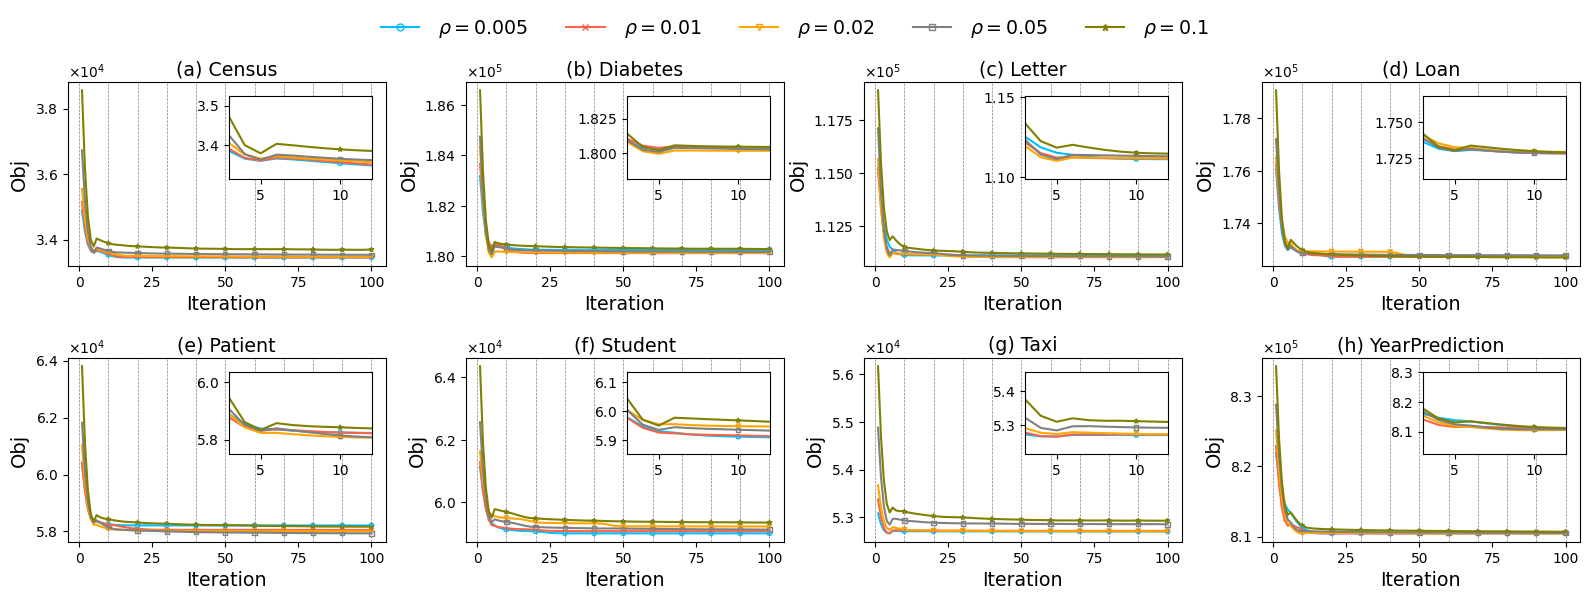

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib as mpl
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
markers = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["$\\rho=0.005$", "$\\rho=0.01$", "$\\rho=0.02$", "$\\rho=0.05$", "$\\rho=0.1$"]
titles = ["(a) Census","(b) Diabetes","(c) Letter","(d) Loan","(e) Patient","(f) Student","(g) Taxi","(h) YearPrediction"]


df = pd.read_csv('./fig3.csv', encoding='utf-8-sig').to_numpy()

makesize = np.zeros(len(df[0]))
makesize[np.mod(df[0], 10) == 0] = 10

fs = 14
fig, axs = plt.subplots(2, 4, figsize=(16, 5.6)) 
fig.tight_layout()

def smooth_data(data):
    return savgol_filter(data, window_length=10, polyorder=3)

def drawMapWithInset(start_row, row_num, ax, title):
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        ax.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                   edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    ax.set_title(title, fontsize=fs*0.98, pad=5)
    ax.set_ylabel('Obj', fontsize=fs)
    ax.set_xlabel("Iteration", fontsize=fs*0.98)

    for k in range(0, 11, 1):
        ax.axvline(x=k*10, color='gray', linestyle='--', linewidth=0.5)

    axins = inset_axes(ax, width="45%", height="45%", loc='upper right', borderpad=1)

    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        axins.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                      edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    x1, x2 = 3, 12
    idx_range = np.where((df[0] >= x1) & (df[0] <= x2))[0]
    y_vals = []
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        y_vals.extend(smoothed[idx_range])
    y1, y2 = min(y_vals), max(y_vals)
    y1, y2 = y1 * 0.99, y2 * 1.015
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    axins.yaxis.set_major_formatter(formatter)
    axins.get_yaxis().get_offset_text().set_visible(False)

row_num = 5
for i in range(2):
    for j in range(4):
        idx = i * 4 + j
        drawMapWithInset(start_row=idx * row_num, row_num=row_num, ax=axs[i, j], title=titles[idx])

handles = []
for idx in range(row_num):
    handle = mlines.Line2D([], [], linestyle='-', color=colors[idx], marker=markers[idx],
                           markersize=5, markerfacecolor='none', markeredgewidth=markeredgewidth)
    handles.append(handle)

fig.legend(handles, labels, loc='upper center', fontsize=fs*0.98, ncol=5, bbox_to_anchor=(0.5, 1.08),
           fancybox=False, shadow=False, frameon=False, handlelength=2, handletextpad=1)

fig.tight_layout()
fig.subplots_adjust(wspace=0.25, hspace=0.5)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./Loss_per_Dataset.pdf", format="pdf", bbox_inches="tight")
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_29464\793312325.py:36: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_29464\793312325.py:57: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
C:\Users\Administrator\AppData\Local\Temp\ipykernel_29464\793312325.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


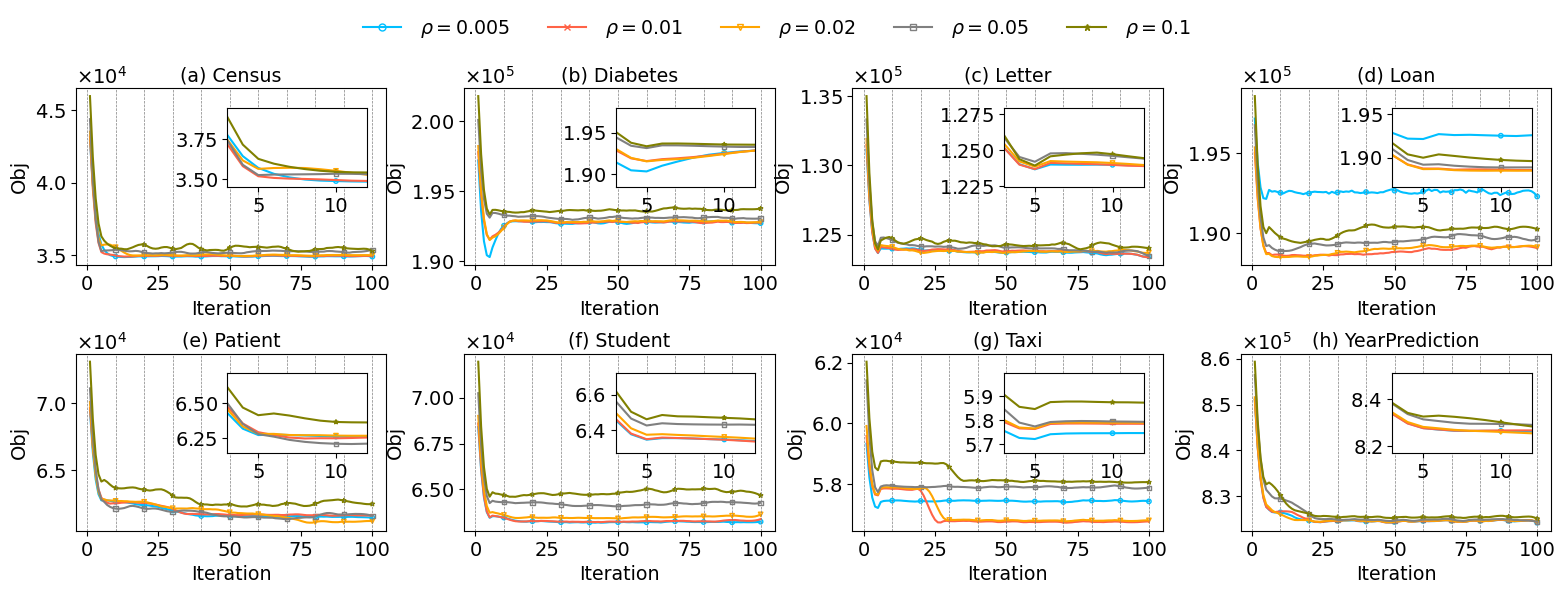

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib as mpl
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
markers = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["$\\rho=0.005$", "$\\rho=0.01$", "$\\rho=0.02$", "$\\rho=0.05$", "$\\rho=0.1$"]
titles = ["(a) Census","(b) Diabetes","(c) Letter","(d) Loan","(e) Patient","(f) Student","(g) Taxi","(h) YearPrediction"]

df = pd.read_csv('./fig3_1.csv', encoding='utf-8-sig').to_numpy()

makesize = np.zeros(len(df[0]))
makesize[np.mod(df[0], 10) == 0] = 10

fs = 14
fig, axs = plt.subplots(2, 4, figsize=(16, 5.6)) 
fig.tight_layout()

def smooth_data(data):
    return savgol_filter(data, window_length=10, polyorder=3)

def drawMapWithInset(start_row, row_num, ax, title):
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        ax.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        ax.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                   edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    ax.set_title(title, fontsize=fs*0.98, pad=5)
    ax.set_ylabel('Obj', fontsize=fs)
    ax.set_xlabel("Iteration", fontsize=fs*0.98)

    for k in range(0, 11, 1):
        ax.axvline(x=k*10, color='gray', linestyle='--', linewidth=0.5)

    axins = inset_axes(ax, width="45%", height="45%", loc='upper right', borderpad=1)

    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        axins.plot(df[0], smoothed, linestyle='-', color=colors[i-1])
        axins.scatter(df[0], smoothed, marker=markers[i-1], s=makesize,
                      edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

    x1, x2 = 3, 12
    idx_range = np.where((df[0] >= x1) & (df[0] <= x2))[0]
    y_vals = []
    for i in range(1, row_num + 1):
        smoothed = smooth_data(df[i + start_row])
        y_vals.extend(smoothed[idx_range])
    y1, y2 = min(y_vals), max(y_vals)
    y1, y2 = y1 * 0.99, y2 * 1.015
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)
    axins.yaxis.set_major_formatter(formatter)
    axins.get_yaxis().get_offset_text().set_visible(False)

row_num = 5
for i in range(2):
    for j in range(4):
        idx = i * 4 + j
        drawMapWithInset(start_row=idx * row_num, row_num=row_num, ax=axs[i, j], title=titles[idx])

handles = []
for idx in range(row_num):
    handle = mlines.Line2D([], [], linestyle='-', color=colors[idx], marker=markers[idx],
                           markersize=5, markerfacecolor='none', markeredgewidth=markeredgewidth)
    handles.append(handle)

fig.legend(handles, labels, loc='upper center', fontsize=fs*0.98, ncol=5, bbox_to_anchor=(0.5, 1.08),
           fancybox=False, shadow=False, frameon=False, handlelength=2, handletextpad=1)

fig.tight_layout()
fig.subplots_adjust(wspace=0.25, hspace=0.5)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./Loss_per_Datasetdp.pdf", format="pdf", bbox_inches="tight")
plt.show()


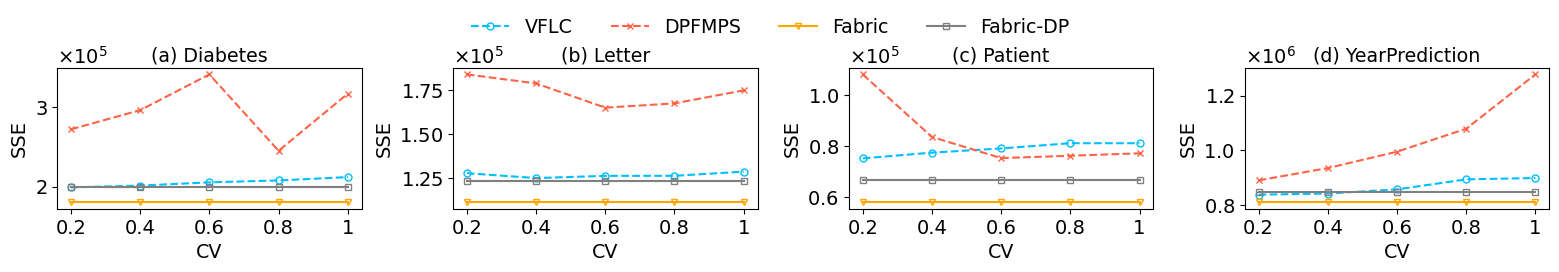

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl

colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
marker = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["VFLC", "DPFMPS", "Fabric", "Fabric-DP", "x", "x"]

df = pd.read_csv('./fig_random.csv')
df = df.to_numpy()

fs = 14
fig, axs = plt.subplots(1, 4, figsize=(16, 2.8))  
makesize = 5

def drawMapWithLabels(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'  
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1],
            label=labels[i - 1]
        )
    # ax.legend(fontsize=fs*0.9)

def drawMap(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1]
        )

row_num = 4
drawMapWithLabels(0, row_num, axs[0])
drawMap(row_num * 1, row_num, axs[1])
drawMap(row_num * 2, row_num, axs[2])
drawMap(row_num * 3, row_num, axs[3])

titles = ["(a) Diabetes", "(b) Letter", "(c) Patient", "(d) YearPrediction"]

fig.legend(loc='upper center',fontsize = fs*0.98, bbox_to_anchor=(0.5, 1.01),
          ncol=10, fancybox=False, shadow=False,frameon=False)


for i in range(4):
    axs[i].set_title(titles[i], fontsize=fs*0.98, pad=5)
    axs[i].set_ylabel('SSE', fontsize=fs)
    axs[i].set_xlabel("CV", fontsize=fs*0.98)
    axs[i].set_xticks([1,2,3,4,5])
    axs[i].set_xticklabels(['0.2','0.4','0.6','0.8','1'])
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    axs[i].yaxis.set_major_formatter(formatter)

fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./varFeature.pdf", format="pdf", bbox_inches="tight")
plt.show()


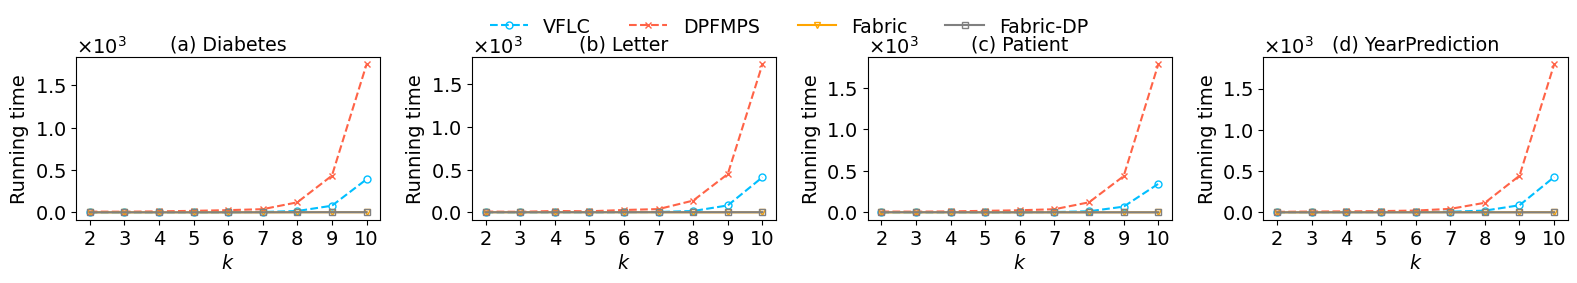

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl

colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
marker = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["VFLC", "DPFMPS", "Fabric", "Fabric-DP", "x", "x"]

df = pd.read_csv('./varClient.csv')
df = df.to_numpy()

fs = 14
fig, axs = plt.subplots(1, 4, figsize=(16, 2.8))  
makesize = 5

def drawMapWithLabels(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'  
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1],
            label=labels[i - 1]
        )
    # ax.legend(fontsize=fs*0.9)

def drawMap(start_row, row_num, ax):
    for i in range(1, row_num + 1):
        linestyle = '-' if i in [row_num - 1, row_num] else '--'
        ax.plot(
            df[0], df[i + start_row],
            linestyle=linestyle,
            marker=marker[i - 1],
            markersize=makesize,
            markerfacecolor='none',
            markeredgewidth=markeredgewidth,
            color=colors[i - 1]
        )

row_num = 4
drawMapWithLabels(0, row_num, axs[0])
drawMap(row_num * 1, row_num, axs[1])
drawMap(row_num * 2, row_num, axs[2])
drawMap(row_num * 3, row_num, axs[3])

titles = ["(a) Diabetes", "(b) Letter", "(c) Patient", "(d) YearPrediction"]

fig.legend(loc='upper center',fontsize = fs*0.98, bbox_to_anchor=(0.5, 1.05),
          ncol=10, fancybox=False, shadow=False,frameon=False)


for i in range(4):
    axs[i].set_title(titles[i], fontsize=fs*0.98, pad=5)
    axs[i].set_ylabel('Running time', fontsize=fs)
    axs[i].set_xlabel("$k$", fontsize=fs*0.98)
    axs[i].set_xticks([1,2,3,4,5,6,7,8,9])
    axs[i].set_xticklabels(['2','3','4','5', '6','7','8','9','10'])
    

    
    
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    axs[i].yaxis.set_major_formatter(formatter)

fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./varClient.pdf", format="pdf", bbox_inches="tight")
plt.show()
